# Lab: Relationships Between Categorical Features

A fictional telecommunications company wants to understand which customer groups had the greatest observed churn percentages. A customer **churned** if they left the company during the previous month.

You will use the reproducible analysis workflow:

1. **Question:** What do we want to learn?
2. **Data:** Which observations and features can help answer it?
3. **Operation:** What should the code select, calculate, or compare?
4. **Check:** Does the result have the expected rows, columns, units, and possible values?
5. **Evidence:** Which result directly answers the question?
6. **Conclusion:** What claim is supported?
7. **Limitation:** What should we avoid concluding?


## Learning goals

By the end of this lab, you should be able to:

- identify a target feature;
- describe the distribution of a categorical target;
- create count, joint-percentage, and conditional-percentage cross-tabs;
- choose a normalization direction from the question;
- check the denominator represented by a percentage;
- refine the visual design of a categorical comparison; and
- distinguish an observed relationship from a causal claim.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook's output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

Each row represents one customer in IBM's fictional telecommunications sample.

| Feature | Feature type | Description |
| --- | --- | --- |
| `customer_id` | Identifier | Anonymous customer identifier |
| `contract` | Categorical | Month-to-month, one-year, or two-year contract |
| `internet_service` | Categorical | DSL, fiber optic, or no internet service |
| `tech_support` | Categorical | Technical-support status |
| `payment_method` | Categorical | Customer's payment method |
| `paperless_billing` | Categorical | Whether the customer uses paperless billing |
| `churn` | Categorical target | Whether the customer left during the previous month |

The file contains 7,043 customers and no missing values in these fields. See `data/README.md` for provenance and preparation.


## Prepare the notebook

Import Pandas using its conventional alias `pd` and Matplotlib's `pyplot` component using its conventional alias `plt`.


In [22]:
# Write your code here.
import pandas as pd
import matplotlib.pyplot as plt

## Read the data

Read `data/telco_customer_churn.csv` into a DataFrame named `customers`.


In [23]:
# Write your code here.
customers = pd.read_csv("data/telco_customer_churn.csv")

## Check the data

Display the first five rows.


In [24]:
# Write your code here.
customers.head()

,customer_id,contract,internet_service,tech_support,payment_method,paperless_billing,churn
0,7590-VHVEG,Month-to-month,DSL,No,Electronic check,Yes,No
1,5575-GNVDE,One year,DSL,No,Mailed check,No,No
2,3668-QPYBK,Month-to-month,DSL,No,Mailed check,Yes,Yes
3,7795-CFOCW,One year,DSL,Yes,Bank transfer (automatic),No,No
4,9237-HQITU,Month-to-month,Fiber optic,No,Electronic check,Yes,Yes


## Check the features

Display a summary that includes the feature names, non-missing counts, and Pandas data storage types.


In [25]:
# Write your code here.
customers.info()
# Count the missing values in every feature.
#
# Display the missing-value count for every feature.


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   customer_id        7043 non-null   str  
 1   contract           7043 non-null   str  
 2   internet_service   7043 non-null   str  
 3   tech_support       7043 non-null   str  
 4   payment_method     7043 non-null   str  
 5   paperless_billing  7043 non-null   str  
 6   churn              7043 non-null   str  
dtypes: str(7)
memory usage: 777.4 KB


In [26]:
# Write your code here.
customers.isnull().sum()

customer_id          0
contract             0
internet_service     0
tech_support         0
payment_method       0
paperless_billing    0
churn                0
dtype: int64

A **categorical** feature places observations into groups or labels. A **quantitative** feature records a numerical amount or measurement for which arithmetic is meaningful.


**Complete the table using the results above.** In the data type column, classify each feature as categorical or quantitative. In the data storage type column, record the type reported by Pandas. Different Pandas versions may display text as `str` or `object`.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `customer_id` | Categorical | str | 0 |
| `contract` | Categorical | str | 0 |
| `internet_service` | Categorical | str | 0 |
| `tech_support` | Categorical | str | 0 |
| `payment_method` | Categorical | str | 0 |
| `paperless_billing` | Categorical | str | 0 |
| `churn` | Categorical | str | 0 |


## Identify the target


**Which feature is the target, and what outcome does it represent?**

Your answer: The target is "churn". It represents whether a customer left the company during the previous month or stayed.


## Describe the target distribution with counts

Create and display a Series named `churn_counts`.


In [27]:
# Write your code here.
churn_counts = customers["churn"].value_counts()
churn_counts

churn
No     5174
Yes    1869
Name: count, dtype: int64

**Which target outcome is more frequent?**

Your answer: No is more frequent. Most customers stayed, compared to who churned.


## Describe the target distribution with relative frequencies

Create and display a Series named `churn_percent`.


In [28]:
# Write your code here.
churn_percent = customers["churn"].value_counts(normalize=True) * 100
churn_percent

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

**What percentage of all customers churned?**

Your answer: About 26.5% of customers churned, while 73.5% stayed.


# Analysis 1: Is churn related to contract type?

Follow the analysis workflow from question through limitation.


**Before calculating a cross-tab, which contract type do you predict had the greatest churn percentage? Explain your prediction.**

Your answer: I predict that month-to-month contracts had the greatest churn percentage. Those customers are not locked into a longer commitment, so they can leave more easily than those on one or two year contracts.


## Step 1: Question


The question is: **Is churn related to contract type?**


## Step 2: Data

The relevant features are `contract` and `churn`. Before calculating percentages, compare the raw counts in their joint distribution.

Create and display `contract_churn_counts`, with contract types in the rows and churn outcomes in the columns.

Create and display `contract_churn_counts`, with contract types in the rows and churn outcomes in the columns.


In [29]:
# Write your code here.
contract_churn_counts = pd.crosstab(customers["contract"], customers["churn"])
contract_churn_counts

churn,No,Yes
contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


**Which contract type has the greatest raw number of customers who churned?**

Your answer: Month-to-month, with 1,655.


**Do the raw churn counts establish which contract group was most likely to churn? Explain.**

Your answer: No. The raw counts don't account for how many customers are in each group. To compare likelihood fairly, we need "churn" as a percentage within each contract type.


## Step 3: Operation

To compare likelihood fairly, calculate churn percentages within each contract type. First inspect the group totals.

Recreate the contract/churn cross-tab using `margins=True`.


In [30]:
# Write your code here.
contract_churn_margins = pd.crosstab(customers["contract"], customers["churn"], margins=True)
contract_churn_margins

churn,No,Yes,All
contract,,,
Month-to-month,2220,1655,3875
One year,1307,166,1473
Two year,1647,48,1695
All,5174,1869,7043


**Why do the contract-group totals matter when comparing likelihood?**

Your answer: The totals show how many customers are in each contract group, which is the denominator for churn likelihood. Without them, a big raw churn count could just mean the group is large, not that its customers were more likely to churn.


### Joint percentages

Create and display `contract_joint_percent`. All cells together should add to 100%.


In [31]:
# Write your code here.
contract_joint_percent = pd.crosstab(customers["contract"], customers["churn"], normalize=True) * 100
contract_joint_percent

churn,No,Yes
contract,,
Month-to-month,31.520659,23.498509
One year,18.557433,2.356950
Two year,23.384921,0.681528


## Step 4: Check

Display the sum of every value in `contract_joint_percent`.


In [32]:
# Write your code here.
contract_joint_percent.sum().sum()

np.float64(100.0)

**What denominator does each joint percentage use?**

Your answer: The total number of customers. Each cell is that groups share of everyone in the dataset.


**Does the joint-percentage table directly answer which contract group was most likely to churn?**

Your answer: No. Joint percentages show each combination's share of all customers, still influenced by group size.


### Conditional percentages

Create `churn_within_contract` so each row describes churn outcomes within one contract type.


In [33]:
# Write your code here.
churn_within_contract = pd.crosstab(customers["contract"], customers["churn"], normalize="index") * 100
churn_within_contract

churn,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Check the conditional percentages

Display the sum of each row in `churn_within_contract`.


In [34]:
# Write your code here.
churn_within_contract.sum(axis=1)

contract
Month-to-month    100.0
One year          100.0
Two year          100.0
dtype: float64

**What should every row add to, and why?**

Your answer: Every row should add to 100%. Each row shows the NO and YES churn percentages within one contract type, so the two outcomes together account for all customers in that group.


**Which contract group had the greatest observed churn percentage? Report the percentage.**

Your answer: Month-to-month, at about 42.7%.


**Was your prediction supported?**

Your answer: Yes. I had predicted that month-to-month would have the highest churn.


## Step 5: Evidence

### Visualize the raw counts

Make a stacked bar chart from `contract_churn_counts`.


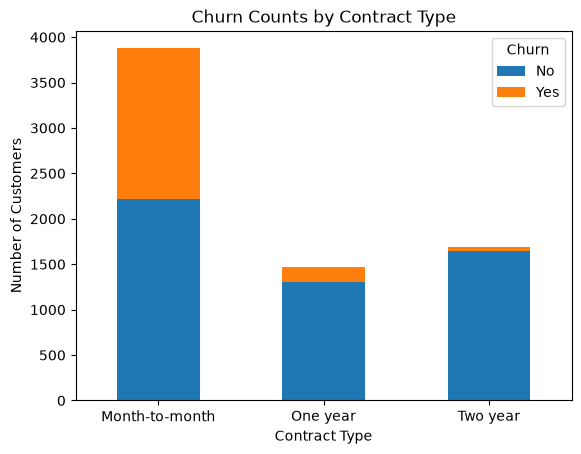

In [35]:
# Write your code here.
contract_churn_counts.plot(kind="bar", stacked=True)
plt.title("Churn Counts by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

### Visualize the conditional percentages

Make a 100% stacked bar chart from `churn_within_contract`. Use:

- `"lightgray"` for customers who did not churn;
- `"steelblue"` for customers who churned;
- a question-focused title;
- descriptive axis labels;
- horizontal x-axis labels; and
- an audience-friendly legend.


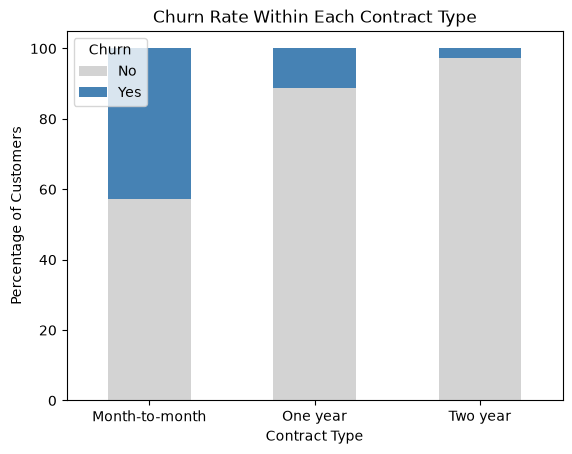

In [36]:
# Write your code here.
churn_within_contract.plot(kind="bar", stacked=True, color=["lightgray", "steelblue"])
plt.title("Churn Rate Within Each Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.show()

**Which chart answers the likelihood question more clearly: counts or conditional percentages? Explain.**

Your answer: The conditional percentages, because every bar is the same height (100%). You can compare the churn share across contract types directly. 


## Step 6: Conclusion


**What conclusion about contract type and churn is supported by this sample?**

Your answer: In this sample, churn is strongly related to contract type.


## Step 7: Limitation


**Why does this analysis not prove that changing a customer's contract would cause a change in churn?**

Your answer: This is an observed relationship, not proof of cause. The data doesn't show that switching a customer to a longer contract would reduce their churn.


# Analysis 2: Is churn related to payment method?

Apply the same workflow to a second pair of categorical features.


## Step 1: Question


The question is: **Is churn related to payment method?**


## Step 2: Data

Create and display the joint distribution of `payment_method` and `churn` as raw counts. Name it `payment_churn_counts`.

Create and display `payment_churn_counts`.


In [37]:
# Write your code here.
payment_churn_counts = pd.crosstab(customers["payment_method"], customers["churn"])
payment_churn_counts

churn,No,Yes
payment_method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


## Step 3: Operation

Create and display `churn_within_payment`.


In [38]:
# Write your code here.
churn_within_payment = pd.crosstab(customers["payment_method"], customers["churn"], normalize="index") * 100
churn_within_payment

churn,No,Yes
payment_method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## Step 4: Check

Display the sum of every row in `churn_within_payment`.


In [39]:
# Write your code here.
churn_within_payment.sum(axis=1)

payment_method
Bank transfer (automatic)    100.0
Credit card (automatic)      100.0
Electronic check             100.0
Mailed check                 100.0
dtype: float64

**Which payment-method group had the greatest observed churn percentage? Report the percentage.**

Your answer: Electronic check, with about 45.3%.


## Step 5: Evidence

Make a 100% stacked bar chart. Choose two readable colors that are different from the `"lightgray"` and `"steelblue"` used in the contract chart. Use the same color consistently for each outcome throughout this chart and include audience-friendly labels.


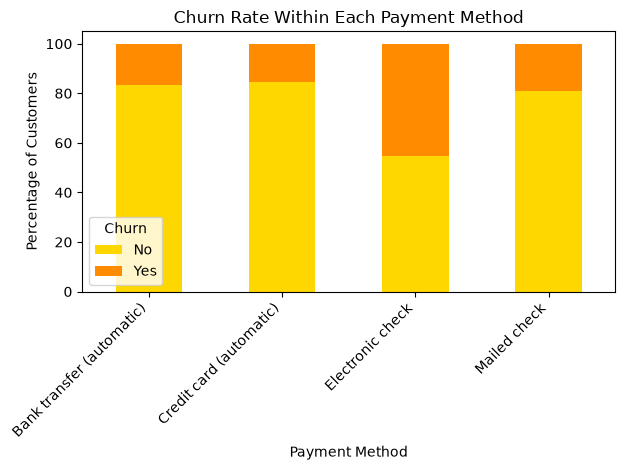

In [40]:
# Write your code here.
churn_within_payment.plot(kind="bar", stacked=True, color=["gold", "darkorange"])
plt.title("Churn Rate Within Each Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage of Customers")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

## Step 6: Conclusion


**What conclusion about payment method and churn is supported by the sample? Include the percentage that provides your strongest evidence.**

Your answer: In this sample, churn is related to payment method. Customers paying by electronic check churned far higher than the other three methods.


## Step 7: Limitation


**Why does this analysis not prove that changing a customer's payment method would cause a change in churn?**

Your answer: The data doesn't show that switching a customer's payment method would change their churn.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that you did not use one.

Your answer: I did use Claude AI to help check my code and talk through the written answers. One suggestion I checked was using "plt.legend(title="Churn") instead of plt.legend("Churn"), which I accepted realizing that I had initially left out "title=" and seeing the legend display "C" and "h" instead of NO and YES. I did verify every percentage in my answers against the notebook output myself.


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Keep code, figures, and written answers neat and easy to read.
- Distinguish an observed relationship from a causal claim.
- Complete the AI-use reflection.
- Submit the completed notebook by the deadline.
